# Pulling Our Data

A short notebook to obtain, inspect and, if necessary, clean our data before saving. 

This notebook should be run before any of the subsequent ones. The resulting csv will be saved to the `data/` folder.

In [17]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [18]:
def get_single_stock_data(ticker, interval="1d", period="max"):
    df = yf.download(tickers=ticker, interval=interval, period=period, group_by="ticker", auto_adjust=True)
    df.columns = df.columns.droplevel(0)
    df.columns.name = None
    df.columns = df.columns.str.lower()
    df.index.name = "date"
    return df


In [19]:
df_pep = get_single_stock_data("PEP")
df_ko = get_single_stock_data("KO")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Inspection 

In [20]:
df_pep

,open,high,low,close,volume
date,,,,,
1972-06-01,0.362517,0.366757,0.362517,0.366757,318600
1972-06-02,0.366756,0.370466,0.365696,0.365696,140400
1972-06-05,0.366759,0.367291,0.354534,0.361444,469800
1972-06-06,0.358255,0.358255,0.357192,0.358255,140400
1972-06-07,0.358255,0.358787,0.355066,0.356129,178200
...,...,...,...,...,...
2026-08-31,139.549211,139.549211,137.857294,138.856613,6555600
2026-09-01,139.697635,139.935088,137.896865,138.312424,5529500
2026-09-02,138.787356,140.212138,137.827608,139.034714,7054500


In [21]:
df_ko

,open,high,low,close,volume
date,,,,,
1962-01-02,0.044457,0.045668,0.044457,0.044457,806400
1962-01-03,0.043797,0.043797,0.042807,0.043467,1574400
1962-01-04,0.043577,0.044127,0.043577,0.043797,844800
1962-01-05,0.043797,0.044347,0.042697,0.042807,1420800
1962-01-08,0.042477,0.042477,0.041541,0.042367,2035200
...,...,...,...,...,...
2026-08-31,89.510002,89.529999,88.599998,88.669998,23764800
2026-09-01,89.589996,89.779999,87.809998,88.000000,14824100
2026-09-02,87.900002,88.949997,87.730003,88.239998,18492800


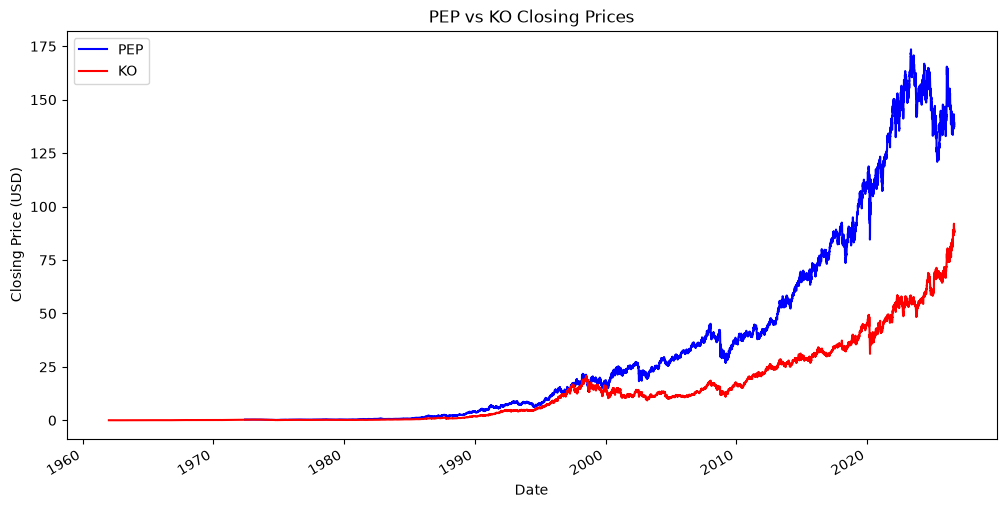

In [22]:
plt.figure(figsize=(12, 6))

df_pep["close"].plot(label="PEP", color="blue")
df_ko["close"].plot(label="KO", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.title("PEP vs KO Closing Prices")

plt.show()

## Completeness Checks

In [23]:
print("First PEP record: ", min(df_pep.index))
print("First KO record: ", min(df_ko.index))

First PEP record:  1972-06-01 00:00:00
First KO record:  1962-01-02 00:00:00


In [24]:
df_ko = df_ko[df_ko.index >= min(df_pep.index)]

In [25]:
df_merged = df_pep.merge(df_ko, on="date", how="outer", suffixes=("_pep", "_ko"), indicator=True)
df_merged.head()

,open_pep,high_pep,low_pep,close_pep,volume_pep,open_ko,high_ko,low_ko,close_ko,volume_ko,_merge
date,,,,,,,,,,,
1972-06-01,0.362517,0.366757,0.362517,0.366757,318600,0.288607,0.289422,0.286706,0.287249,748800,both
1972-06-02,0.366756,0.370466,0.365696,0.365696,140400,0.286706,0.286706,0.285620,0.286163,393600,both
1972-06-05,0.366759,0.367291,0.354534,0.361444,469800,0.286163,0.286706,0.285077,0.285620,662400,both
1972-06-06,0.358255,0.358255,0.357192,0.358255,140400,0.284535,0.284535,0.282634,0.283177,768000,both
1972-06-07,0.358255,0.358787,0.355066,0.356129,178200,0.281819,0.281819,0.279647,0.281819,1420800,both


In [26]:
df_merged.dtypes

open_pep       float64
high_pep       float64
low_pep        float64
close_pep      float64
volume_pep       int64
open_ko        float64
high_ko        float64
low_ko         float64
close_ko       float64
volume_ko        int64
_merge        category
dtype: object

In [27]:
print("PEP only: ", sum(df_merged["_merge"] == "left_only"))
print("KO only: ", sum(df_merged["_merge"] == "right_only"))
print("both: ", sum(df_merged["_merge"] == "both"))

PEP only:  0
KO only:  0
both:  13679


In [28]:
df_merged.drop(columns="_merge", inplace=True)

In [29]:
def completeness_check(df):
    issue_found = False

    for col in df.columns:
        zeros = sum(df[col] == 0)
        negatives = sum(df[col] < 0)
        nulls = sum(df[col].isna())
        if zeros != 0:
            issue_found = True
            print(zeros, " zero(s) found in ", col)
        if negatives != 0:
            issue_found = True
            print(negatives, " negative(s) found in ", col)
        if nulls != 0:
            issue_found = True
            print(nulls, " null(s) found in ", col)

    if not issue_found:
        print("dataset is complete!")

In [30]:
completeness_check(df_merged)

1  zero(s) found in  volume_pep


In [31]:
df_merged[df_merged['volume_pep'] == 0]

,open_pep,high_pep,low_pep,close_pep,volume_pep,open_ko,high_ko,low_ko,close_ko,volume_ko
date,,,,,,,,,,
1975-04-11,0.269047,0.269047,0.269047,0.269047,0,0.174908,0.17577,0.174046,0.174908,1939200


Note: if we use volume in our analysis we must deal with the above date.

## Saving

In [32]:
df_merged.to_csv("../data/pep_ko_daily_close_data.csv", index=True)